In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/global_cancer_patients_2015_2024.csv")

In [ ]:
df.head()

,Patient_ID,Age,Gender,Country_Region,Years,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [ ]:
df.tail()

,Patient_ID,Age,Gender,Country_Region,Years,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
49995,PT0049995,80,Male,Pakistan,2023,2.3,7.5,2.8,3.8,2.9,Leukemia,Stage 0,71463.70,1.0,3.63
49996,PT0049996,40,Female,USA,2018,6.4,3.5,2.9,9.0,9.8,Colon,Stage I,49619.66,0.4,6.03
49997,PT0049997,74,Male,Pakistan,2015,6.2,1.6,8.7,4.7,4.0,Breast,Stage 0,5338.25,2.7,6.02
49998,PT0049998,21,Male,Brazil,2018,4.0,6.5,7.6,8.6,8.1,Liver,Stage IV,45100.47,7.5,6.54
49999,PT0049999,22,Male,Pakistan,2023,5.1,9.8,3.2,0.0,0.7,Liver,Stage 0,64023.82,7.4,3.76


In [ ]:
df.describe()

,Age,Years,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.421540,2019.480520,5.001698,5.010126,5.010880,4.989826,4.991176,52467.298239,5.006462,4.951207
std,20.224451,2.871485,2.885773,2.888399,2.888769,2.881579,2.894504,27363.229379,2.883335,1.199677
min,20.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5000.050000,0.000000,0.900000
25%,37.000000,2017.000000,2.500000,2.500000,2.500000,2.500000,2.500000,28686.225000,2.500000,4.120000
50%,54.000000,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,52474.310000,5.000000,4.950000
75%,72.000000,2022.000000,7.500000,7.500000,7.500000,7.500000,7.500000,76232.720000,7.500000,5.780000
max,89.000000,2024.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99999.840000,10.000000,9.160000


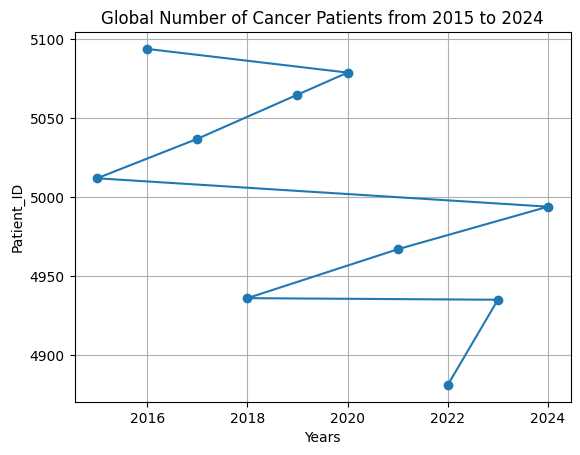

,Patient_ID
Years,
2016,5094
2020,5079
2019,5065
2017,5037
2015,5012
2024,4994
2021,4967
2018,4936
2023,4935


In [ ]:
# How has the global number of cancer patients changed from 2015 to 2024?
global_number = df.groupby('Years')['Patient_ID'].count().sort_values(ascending=False)

plt.plot(global_number.index, global_number.values, marker = 'o')
plt.title("Global Number of Cancer Patients from 2015 to 2024")
plt.xlabel("Years")
plt.ylabel("Patient_ID")
plt.grid(True)
plt.show()
global_number

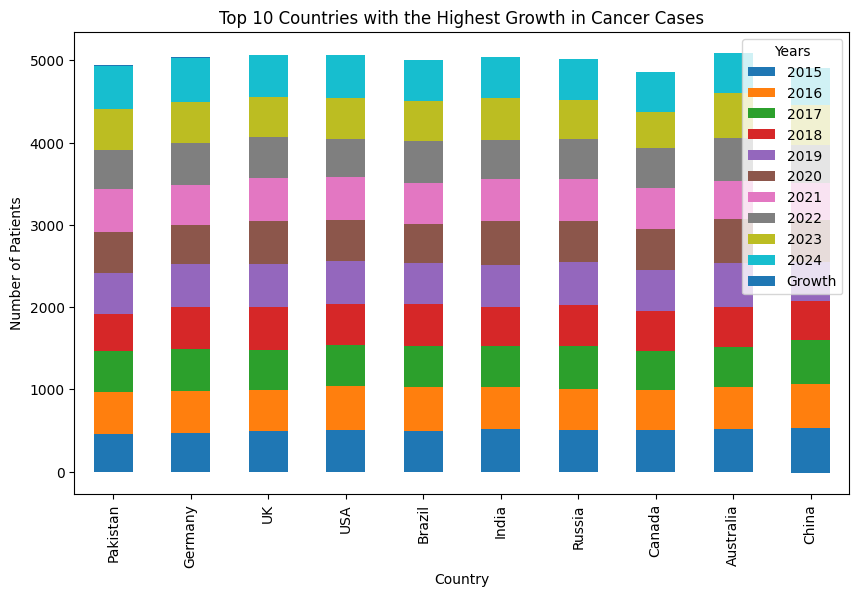

Years,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Growth
Country_Region,,,,,,,,,,,
Pakistan,460,506,499,451,500,501,517,481,490,521,13.260870
Germany,473,503,512,517,519,478,484,507,503,528,11.627907
UK,490,499,493,524,522,525,513,497,488,509,3.877551
USA,508,533,494,507,517,500,521,468,498,514,1.181102
Brazil,499,525,508,504,496,485,492,506,491,498,-0.200401
India,515,508,507,477,504,532,519,470,505,503,-2.330097
Russia,512,493,524,501,515,507,504,492,473,496,-3.125000
Canada,511,478,481,489,490,502,501,487,437,488,-4.500978
Australia,515,516,484,492,525,535,472,513,554,486,-5.631068


In [ ]:
# Which countries show the highest growth or decline in cancer cases over the years?
country_growth = df.groupby(['Country_Region','Years']).size().unstack(fill_value=0)
country_growth['Growth'] = ((country_growth[2024]-country_growth[2015])/country_growth[2015])*100
top_growth = country_growth.sort_values(by='Growth', ascending=False)

top_growth.head(10).plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Top 10 Countries with the Highest Growth in Cancer Cases")
plt.xlabel("Country")
plt.ylabel("Number of Patients")
plt.show()
top_growth

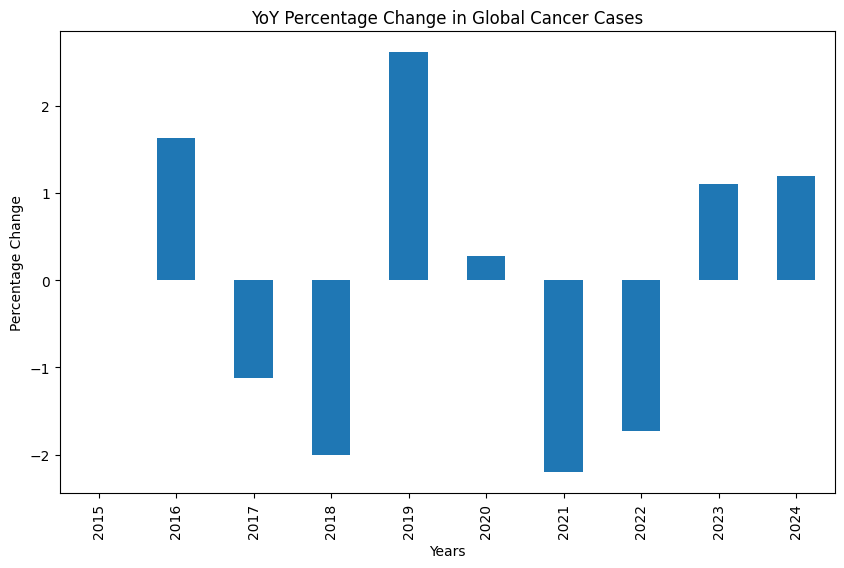

,Patient_ID
Years,
2015,NaN
2016,1.636073
2017,-1.118963
2018,-2.005162
2019,2.613452
2020,0.276407
2021,-2.205158
2022,-1.731427
2023,1.106331


In [6]:
#What is the year-over-year (YoY) percentage change in global cancer cases?
yoy_change = df.groupby('Years')['Patient_ID'].count().pct_change() * 100
yoy_change.plot(kind='bar', figsize=(10, 6))
plt.title("YoY Percentage Change in Global Cancer Cases")
plt.xlabel("Years")
plt.ylabel("Percentage Change")
plt.show()
yoy_change

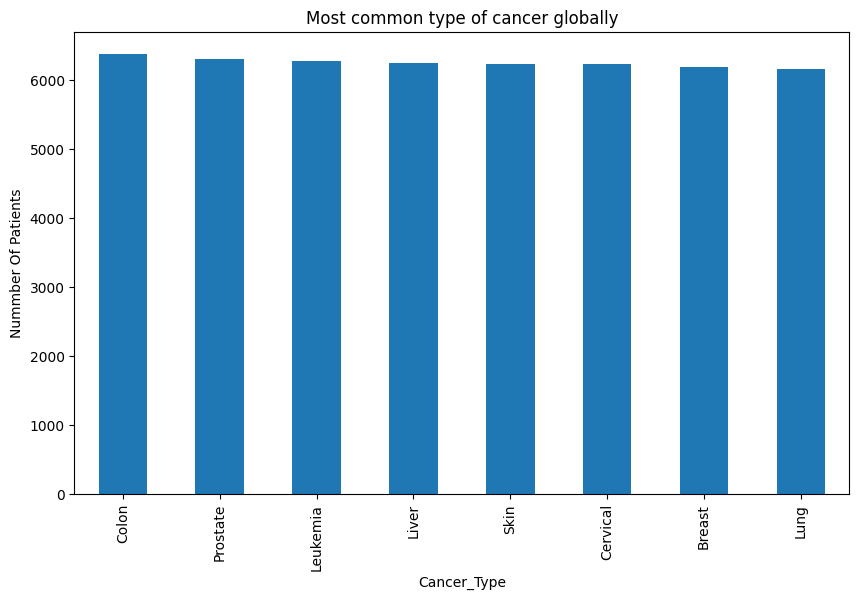

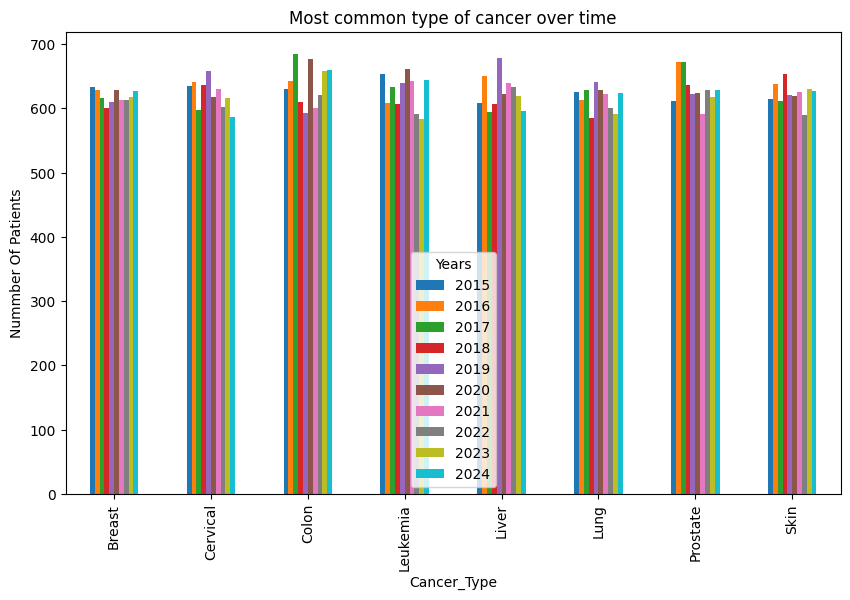

In [13]:
#Which types of cancer are most common globally
cancer_type = df.groupby('Cancer_Type')['Patient_ID'].count().sort_values(ascending = False)
cancer_type
cancer_type.plot(kind='bar' ,figsize=(10,6))
plt.title("Most common type of cancer globally")
plt.xlabel("Cancer_Type")
plt.ylabel("Nummber Of Patients")
plt.show()

# how have their trends changed over time?
cancer_type_year = df.groupby(['Cancer_Type','Years']).size().unstack(fill_value=0)
cancer_type_year
cancer_type_year.plot(kind='bar',figsize=(10,6))
plt.title("Most common type of cancer over time")
plt.xlabel("Cancer_Type")
plt.ylabel("Nummber Of Patients")
plt.show()

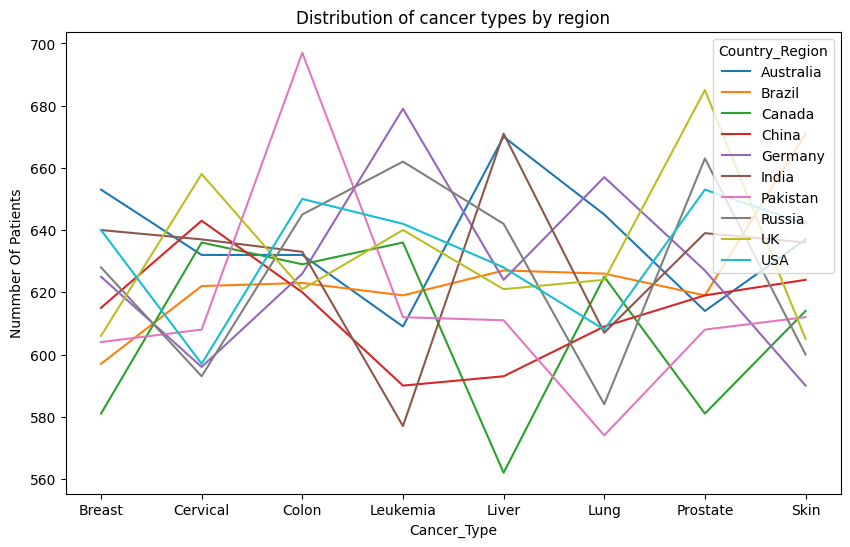

In [21]:
#What is the distribution of cancer types by region (continent, country)?
cancer_type_by_region = df.groupby(['Cancer_Type','Country_Region']).size().unstack(fill_value=0)
cancer_type_by_region
cancer_type_by_region.plot(kind='line',figsize=(10,6))
plt.title("Distribution of cancer types by region")
plt.xlabel("Cancer_Type")
plt.ylabel("Nummber Of Patients")
plt.show()

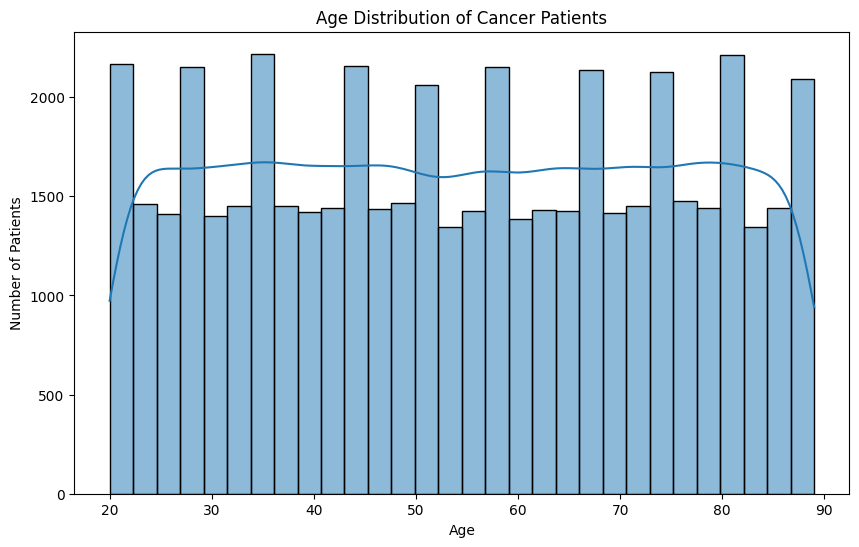

In [42]:
#What is the age distribution of cancer patients?
age_distribution = df.groupby('Age')['Patient_ID'].count().sort_values(ascending=False)
age_distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age',  bins=30,kde=True)

plt.title("Age Distribution of Cancer Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()


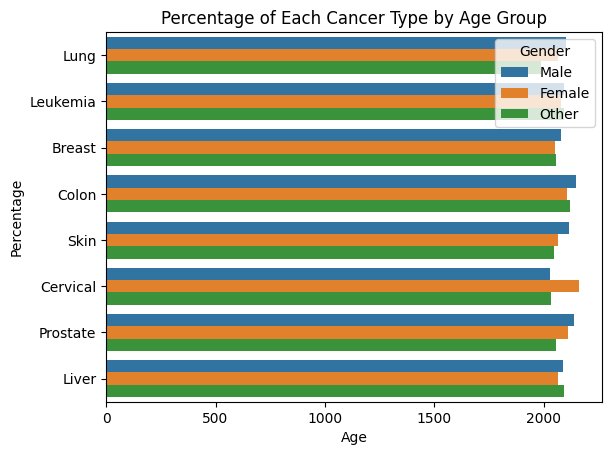

Cancer_Type,Breast,Cervical,Colon,Leukemia,Liver,Lung,Prostate,Skin
Gender,,,,,,,,
Female,2051,2160,2108,2081,2064,2067,2113,2065
Male,2080,2028,2147,2092,2091,2103,2138,2117
Other,2058,2034,2121,2093,2094,1989,2057,2049


In [48]:
#What is the gender distribution among cancer patients overall and by cancer type?
gender_group_cancer_type = df.groupby(['Gender','Cancer_Type']).size().unstack(fill_value=0)


sns.countplot(data=df,y='Cancer_Type',hue='Gender')
plt.title("Percentage of Each Cancer Type by Age Group")
plt.xlabel("Age")
plt.ylabel("Percentage")
plt.show()

gender_group_cancer_type

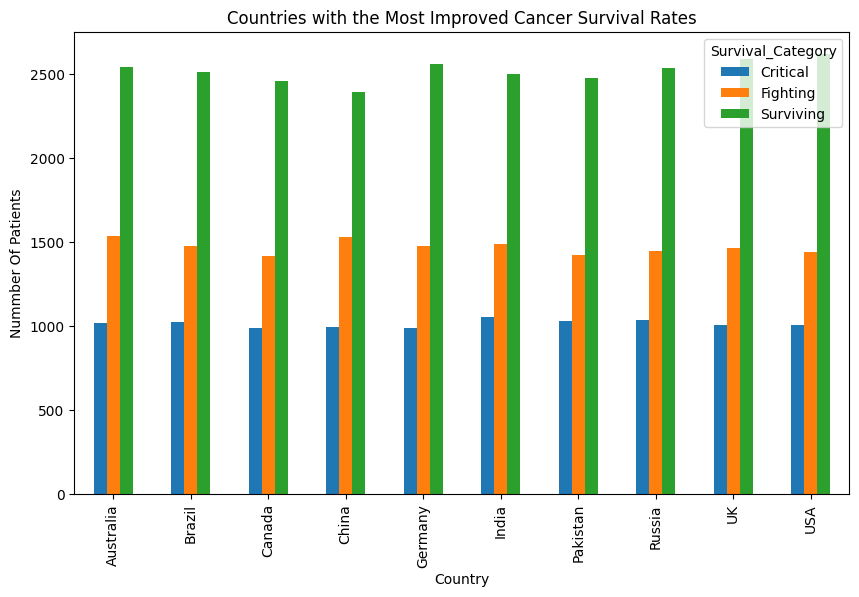

Survival_Category,Critical,Fighting,Surviving
Country_Region,,,
Australia,1017,1537,2538
Brazil,1020,1475,2509
Canada,990,1415,2459
China,995,1526,2392
Germany,987,1478,2559
India,1054,1487,2499
Pakistan,1029,1423,2474
Russia,1036,1446,2535
UK,1005,1465,2590


In [62]:
#Which countries have improved their cancer survival rates the most (if survival data available)?
def survival_category(Survival_Years):
    if Survival_Years >= 5:
        return 'Surviving'
    else:
        if 2 < Survival_Years < 5:
            return 'Fighting'
        else:
            return 'Critical'


df['Survival_Category'] = df['Survival_Years'].apply(survival_category)
survival_rate = df.groupby(['Country_Region','Survival_Category']).size().unstack(fill_value=0)
survival_rate.plot(kind='bar',figsize=(10,6))
plt.title("Countries with the Most Improved Cancer Survival Rates")
plt.xlabel("Country")
plt.ylabel("Nummber Of Patients")
plt.show()
survival_rate
